# 📡 Telecom Customer Data Science Project

## Project Overview

This project performs an exploratory Data Science analysis of a telecom customer dataset.

The project follows a complete beginner-friendly workflow:

**Data Loading → Data Inspection → Data Cleaning → Exploratory Data Analysis → Visualisation → Correlation Analysis → Customer/Churn Analysis → Findings → Conclusion**

### Tools Used
Python, Pandas, NumPy, Matplotlib and Seaborn.

> **Note:** The dataset is embedded inside this notebook. Therefore, this is a **single-file project** and does not require the CSV file separately when opened in Google Colab.


# 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from io import StringIO

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

print("Libraries imported successfully.")


Libraries imported successfully.


# 2. Load the Dataset

In [2]:
csv_data = 'PID,Blue,Wi_Fi,Tch_Scr,Ext_Mem,Px_h,Px_w,Scr_h,Scr_w,PC,FC,Int_Mem,Bty_Pwr,RAM,Depth,Weight,Price\nAAB346A,yes,yes,no,no,780,460,3,1,2,2,8,2800,2,7,320,3297\nAAC347I,yes,yes,no,no,780,560,2,1,4,2,8,3000,2,7,280,4500\nBAB657J,no,yes,no,no,840,720,2,1,4,2,8,3300,2,7,400,4898\nBBD456K,no,yes,yes,no,1280,1120,5,3,6,2,32,3000,2,3,300,6900\nCCP761U,no,yes,yes,no,1280,1080,4,3,6,2,16,3000,2,3,210,5600\nCCQ674K,yes,no,no,no,1280,1080,4,3,6,4,8,2980,2,3,230,4990\nCTX123L,yes,no,yes,no,1390,1080,6,3,8,4,32,3000,2,3,100,13400\nDFR256N,yes,no,no,no,2880,2120,8,6,12,8,32,3200,2,3,80,15600\nDGS789M,yes,yes,yes,yes,2580,1920,6,3,32,16,8,2800,6,3,120,27688\nENG897N,yes,yes,yes,yes,2580,1980,5,3,64,32,64,4380,4,3,150,23456\nEOP657N,yes,yes,yes,yes,2580,1920,6,3,32,16,128,2800,4,4,210,35460\nELS333L,yes,yes,yes,yes,2580,1920,8,6,64,32,8,4500,8,4,150,43980\nETT987D,no,yes,yes,yes,2580,1980,6,5,64,32,64,4500,6,4,300,28700\nNAJ56GL,no,yes,yes,no,2880,2120,6,5,32,16,64,2800,6,4,270,23600\nNBN329S,yes,yes,yes,yes,2380,1820,5,3,16,8,8,2800,4,4,80,21972\nNSD450I,no,no,yes,yes,1980,1760,10,8,16,16,128,3900,6,4,180,23456\nPDF768G,no,no,yes,yes,2580,1980,8,6,64,32,128,3300,4,3,160,22650\nPDG234M,no,no,yes,yes,2880,2120,8,6,8,8,64,2800,4,3,250,19806\nPEL111K,no,no,yes,yes,1980,1760,8,6,12,4,8,4000,4,3,330,11388\nPNWD777L,no,no,yes,yes,2880,2120,4,3,24,12,64,2800,4,3,200,14350\nPOP857R,no,yes,yes,yes,1980,1760,4,3,32,16,16,2800,4,3,150,24560\nQWR222Y,no,yes,yes,yes,2580,1980,8,6,64,32,128,4400,4,3,160,21350\nQZR577O,no,yes,yes,yes,1440,1280,4,3,8,8,64,2800,8,3,170,16999\nRAY344W,no,yes,yes,yes,2880,2120,10,8,8,4,16,4800,8,3,170,18900\nRBZ451D,no,yes,yes,yes,1440,1280,6,4,8,4,32,2800,8,3,150,17890\nSDO555G,no,yes,yes,yes,2580,1980,6,3,64,32,64,4500,8,3,210,22000\nSET568R,no,yes,yes,yes,1980,1280,5,3,8,4,128,4500,8,3,220,41320\nSFK567Y,yes,yes,yes,yes,2580,2120,8,6,64,16,32,4300,8,3,200,49899\nSSD000L,yes,yes,yes,yes,2580,2120,8,6,64,32,512,4200,8,3,270,36555\nSYL888P,no,yes,yes,yes,2580,2120,8,6,64,16,256,5000,8,3,320,32459\nTVF078Y,yes,yes,yes,yes,2580,2120,8,6,64,32,512,4860,8,3,90,29999\nTYQ109G,no,yes,yes,yes,2580,2120,8,6,32,16,256,3300,8,3,110,45899\nTYS938L,yes,yes,yes,yes,2580,2120,8,6,64,32,1024,4860,8,3,120,46777\nTYU444Q,no,yes,yes,yes,2580,2120,8,6,64,32,128,2800,8,3,120,45680\nTYY453J,yes,yes,yes,yes,2880,2120,6,3,64,32,128,4400,8,4,150,61750\nULI999T,no,yes,yes,yes,2440,2120,5,3,32,16,64,2800,8,4,210,42000\nUST000T,yes,yes,yes,yes,2580,1980,10,8,64,32,32,3000,4,4,240,34589\nUSZ111S,yes,yes,yes,yes,2440,1980,5,3,48,32,128,4800,4,4,230,42300\nVWV532Y,yes,yes,yes,yes,2580,1920,5,3,64,32,32,4860,8,4,310,39781\nVYI666I,yes,yes,yes,yes,2440,1980,6,5,32,16,32,3200,4,4,180,33460\nWER765T,yes,yes,yes,yes,2580,1980,5,3,64,32,128,3000,4,4,120,34780\nWUV902Y,yes,yes,yes,yes,2580,1980,8,6,48,16,128,3400,4,3,140,28000\nWZB298K,yes,yes,yes,yes,2580,1980,8,6,64,32,1024,5600,8,3,160,39000\nXKL901R,no,yes,yes,yes,2580,1980,8,6,32,16,256,3900,4,3,210,54320\nXTL675G,yes,yes,yes,yes,2580,1980,10,8,64,32,512,4560,8,3,260,51230\nXXV567F,no,yes,yes,yes,2580,1980,8,6,64,32,64,2300,4,3,250,43990\nYTR67TY,yes,yes,yes,yes,2580,1980,4,3,64,32,64,2800,4,3,200,56000\nZDF789K,yes,yes,yes,no,2880,2520,8,6,64,32,512,5600,12,2,80,84566\nZEO567M,yes,yes,yes,no,2880,2520,8,6,128,64,512,5600,12,2,110,88999\nZZZ909X,yes,yes,yes,no,2880,2520,8,6,128,64,1024,5600,12,2,130,149000\n'
df = pd.read_csv(StringIO(csv_data))

print("Dataset loaded successfully.")
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])
display(df.head())


Dataset loaded successfully.
Number of rows: 50
Number of columns: 17


,PID,Blue,Wi_Fi,Tch_Scr,Ext_Mem,Px_h,Px_w,Scr_h,Scr_w,PC,FC,Int_Mem,Bty_Pwr,RAM,Depth,Weight,Price
0,AAB346A,yes,yes,no,no,780,460,3,1,2,2,8,2800,2,7,320,3297
1,AAC347I,yes,yes,no,no,780,560,2,1,4,2,8,3000,2,7,280,4500
2,BAB657J,no,yes,no,no,840,720,2,1,4,2,8,3300,2,7,400,4898
3,BBD456K,no,yes,yes,no,1280,1120,5,3,6,2,32,3000,2,3,300,6900
4,CCP761U,no,yes,yes,no,1280,1080,4,3,6,2,16,3000,2,3,210,5600


# 3. Dataset Inspection

In [3]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
display(df.dtypes.to_frame("Data Type"))

print("\nFirst 5 Records:")
display(df.head())


Dataset Shape: (50, 17)

Column Names:
['PID', 'Blue', 'Wi_Fi', 'Tch_Scr', 'Ext_Mem', 'Px_h', 'Px_w', 'Scr_h', 'Scr_w', 'PC', 'FC', 'Int_Mem', 'Bty_Pwr', 'RAM', 'Depth', 'Weight', 'Price']

Data Types:


,Data Type
PID,object
Blue,object
Wi_Fi,object
Tch_Scr,object
Ext_Mem,object
Px_h,int64
Px_w,int64
Scr_h,int64
Scr_w,int64
PC,int64



First 5 Records:


,PID,Blue,Wi_Fi,Tch_Scr,Ext_Mem,Px_h,Px_w,Scr_h,Scr_w,PC,FC,Int_Mem,Bty_Pwr,RAM,Depth,Weight,Price
0,AAB346A,yes,yes,no,no,780,460,3,1,2,2,8,2800,2,7,320,3297
1,AAC347I,yes,yes,no,no,780,560,2,1,4,2,8,3000,2,7,280,4500
2,BAB657J,no,yes,no,no,840,720,2,1,4,2,8,3300,2,7,400,4898
3,BBD456K,no,yes,yes,no,1280,1120,5,3,6,2,32,3000,2,3,300,6900
4,CCP761U,no,yes,yes,no,1280,1080,4,3,6,2,16,3000,2,3,210,5600


# 4. Data Cleaning

Before analysis, the dataset is checked for missing values and duplicate records. Column names are also standardised so that they are easier to use in Python.


In [4]:
df.columns = (
    df.columns.astype(str)
      .str.strip()
      .str.lower()
      .str.replace(r"[^a-z0-9]+", "_", regex=True)
      .str.strip("_")
)

print("Missing Values:")
display(df.isnull().sum().to_frame("Missing Values"))

duplicate_count = int(df.duplicated().sum())
print("Duplicate rows:", duplicate_count)

df = df.drop_duplicates().reset_index(drop=True)
print("Shape after cleaning:", df.shape)


Missing Values:


,Missing Values
pid,0
blue,0
wi_fi,0
tch_scr,0
ext_mem,0
px_h,0
px_w,0
scr_h,0
scr_w,0
pc,0


Duplicate rows: 0
Shape after cleaning: (50, 17)


# 5. Descriptive Statistics

In [5]:
print("Numerical Statistics:")
display(df.describe().T)

print("\nCategorical Statistics:")
display(df.describe(include="object").T)


Numerical Statistics:


,count,mean,std,min,25%,50%,75%,max
px_h,50.0,2319.40,598.400623,780.0,2080.0,2580.0,2580.0,2880.0
px_w,50.0,1833.20,469.713069,460.0,1775.0,1980.0,2120.0,2520.0
scr_h,50.0,6.50,2.042907,2.0,5.0,6.0,8.0,10.0
scr_w,50.0,4.62,1.883223,1.0,3.0,5.0,6.0,8.0
pc,50.0,42.16,30.174567,2.0,12.0,40.0,64.0,128.0
fc,50.0,20.76,14.784934,2.0,8.0,16.0,32.0,64.0
int_mem,50.0,173.76,261.771871,8.0,32.0,64.0,128.0,1024.0
bty_pwr,50.0,3740.00,958.817299,2300.0,2800.0,3300.0,4500.0,5600.0
ram,50.0,5.76,2.759473,2.0,4.0,5.0,8.0,12.0
depth,50.0,3.44,1.052887,2.0,3.0,3.0,4.0,7.0



Categorical Statistics:


,count,unique,top,freq
pid,50,50,AAB346A,1
blue,50,2,yes,27
wi_fi,50,2,yes,42
tch_scr,50,2,yes,45
ext_mem,50,2,yes,38


# 6. Numerical Variable Analysis

Numerical columns: ['px_h', 'px_w', 'scr_h', 'scr_w', 'pc', 'fc', 'int_mem', 'bty_pwr', 'ram', 'depth', 'weight', 'price']


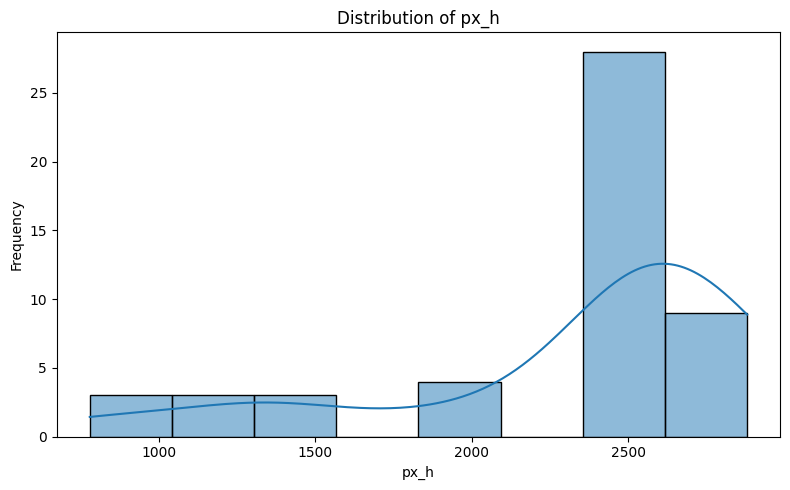

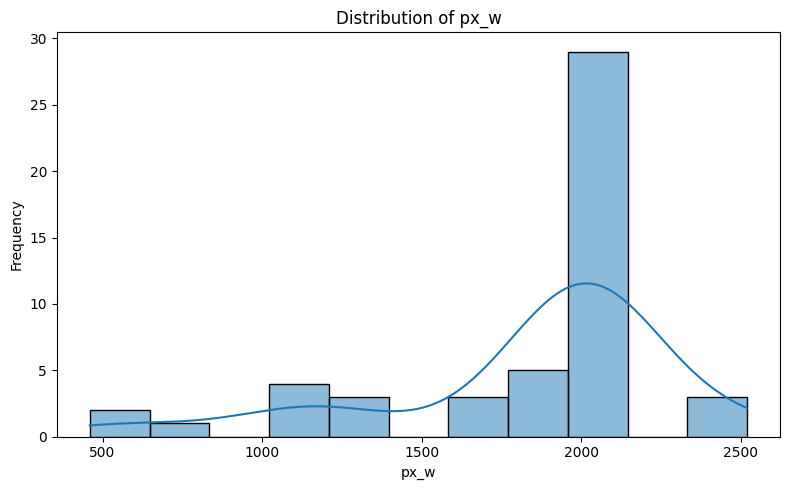

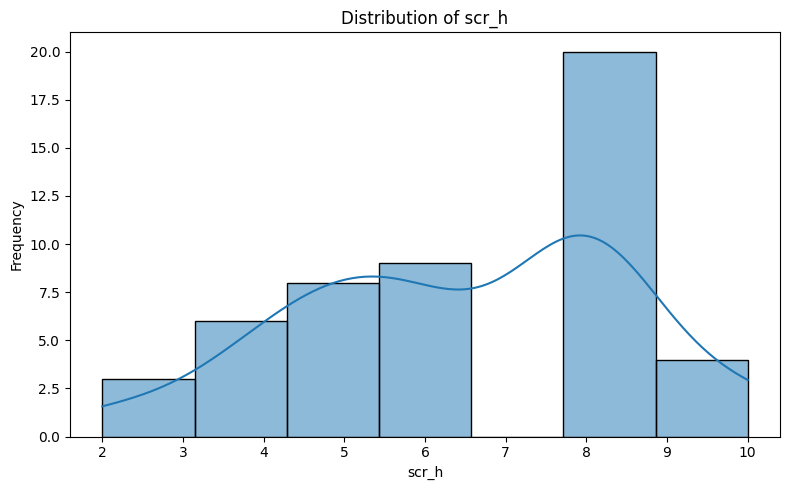

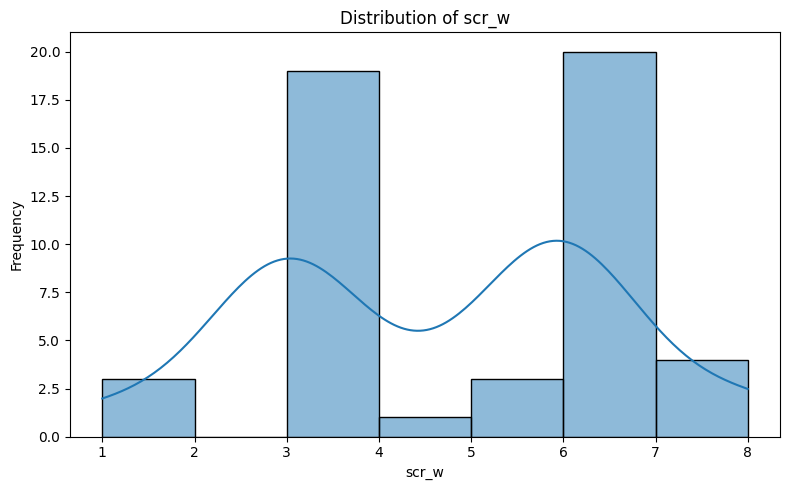

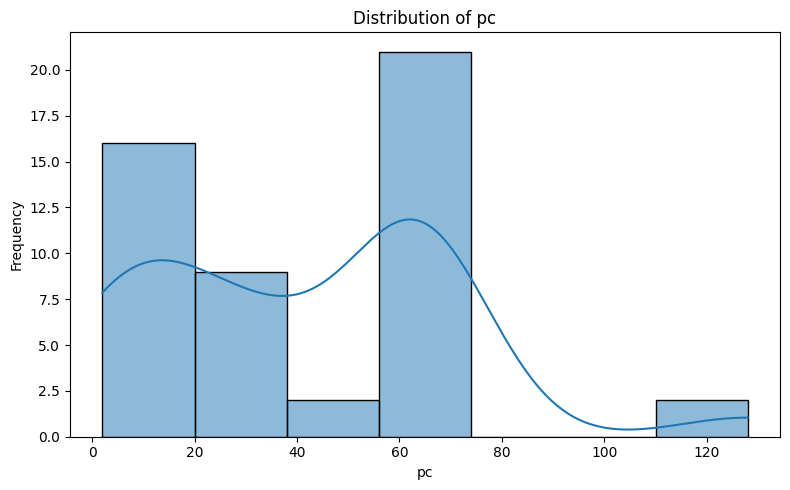

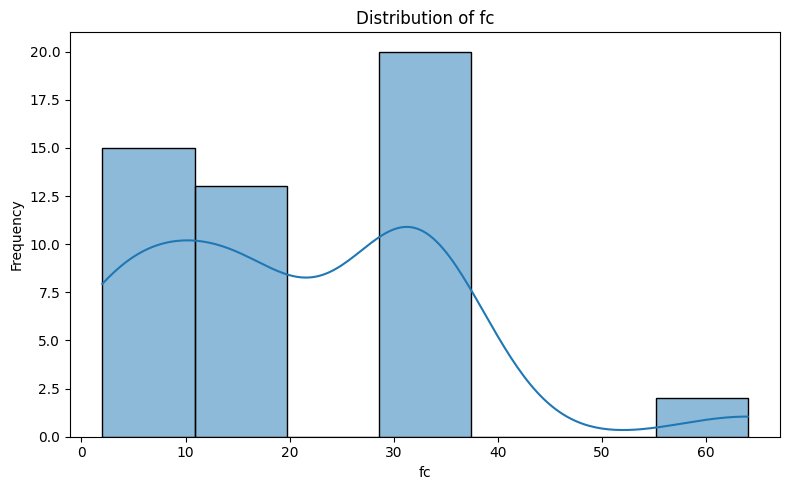

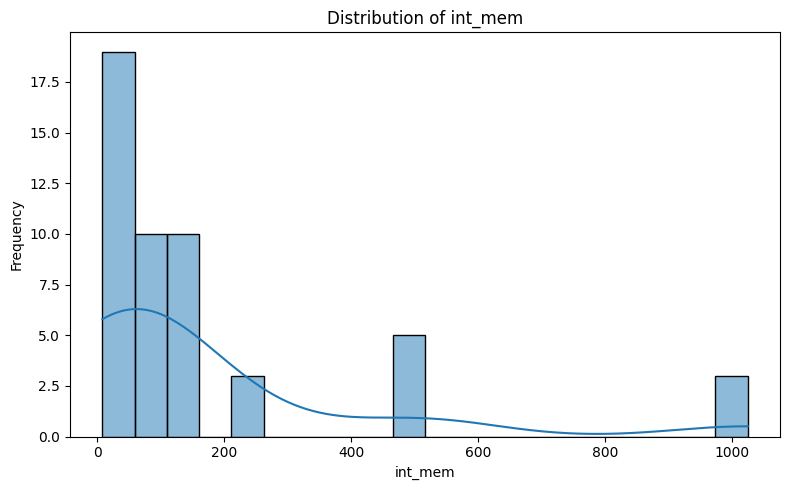

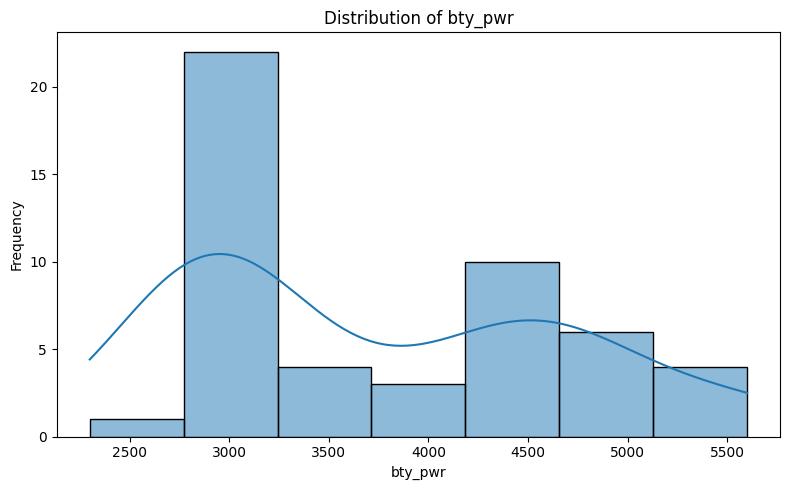

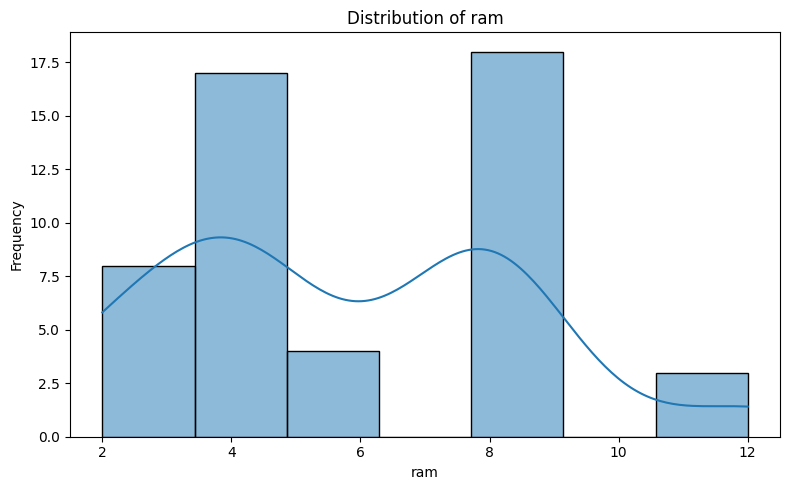

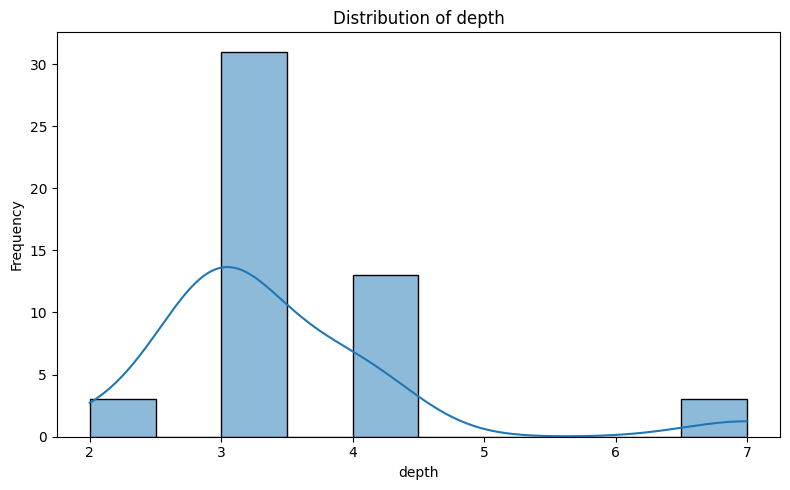

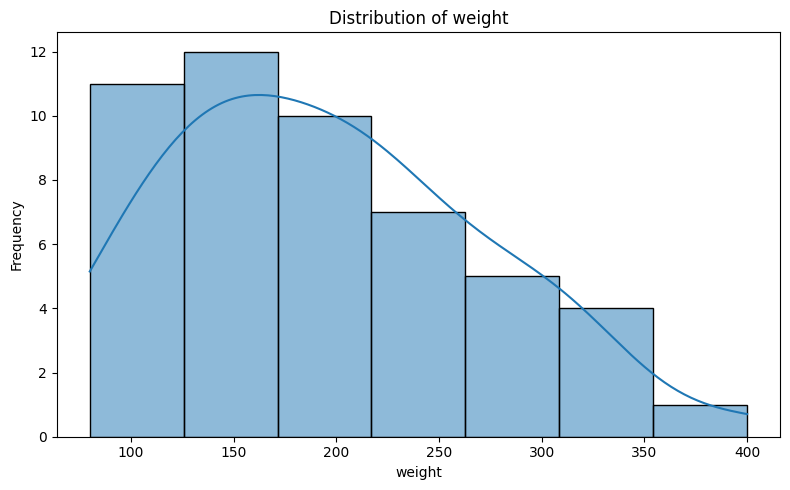

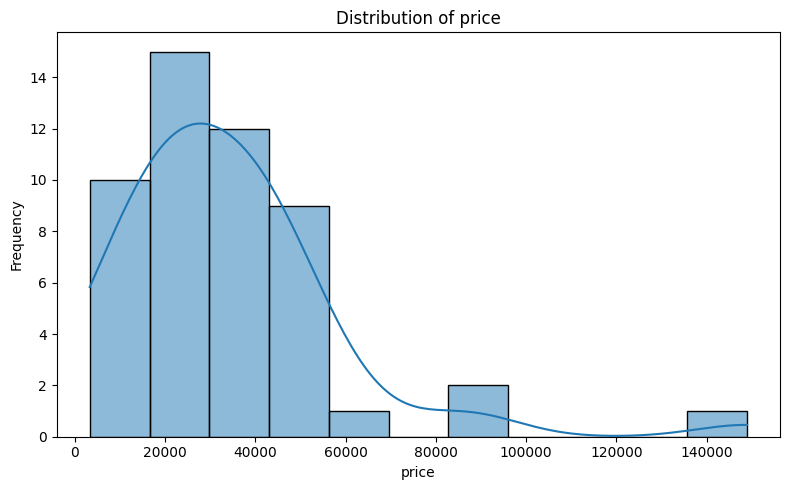

In [6]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
print("Numerical columns:", numeric_cols)

for col in numeric_cols:
    plt.figure(figsize=(8, 5))
    sns.histplot(df[col].dropna(), kde=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()


# 7. Categorical Variable Analysis

Categorical columns: ['pid', 'blue', 'wi_fi', 'tch_scr', 'ext_mem']


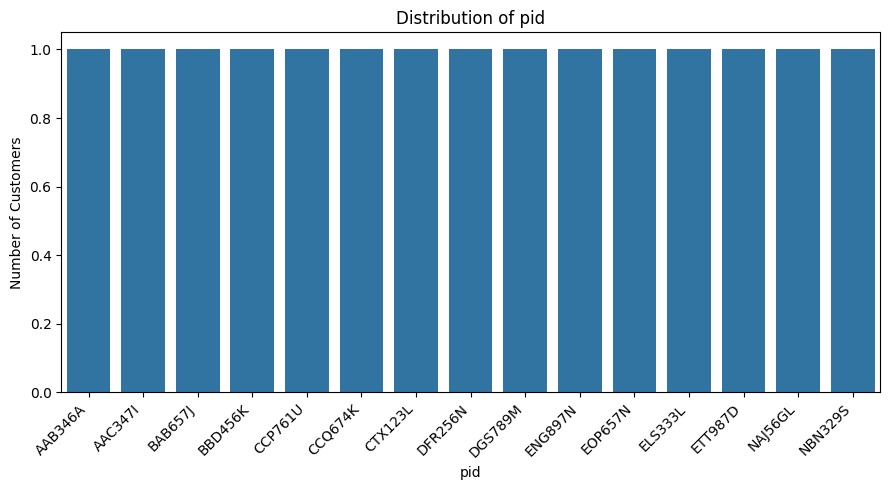

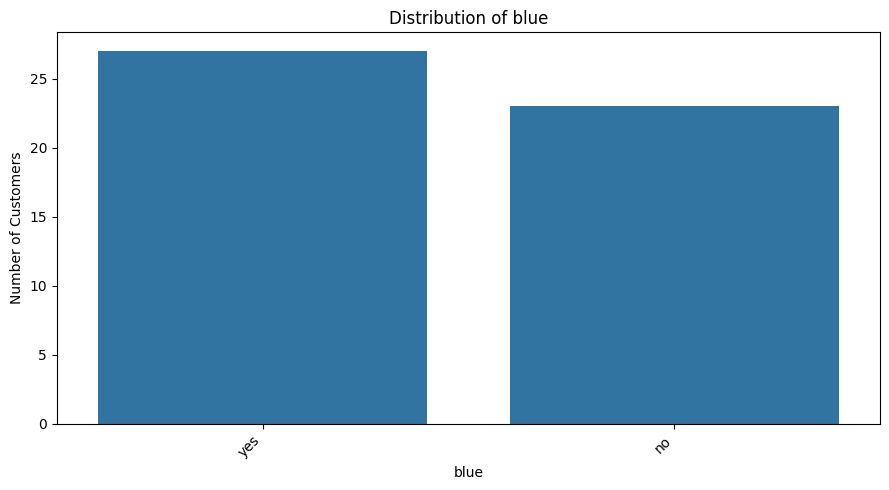

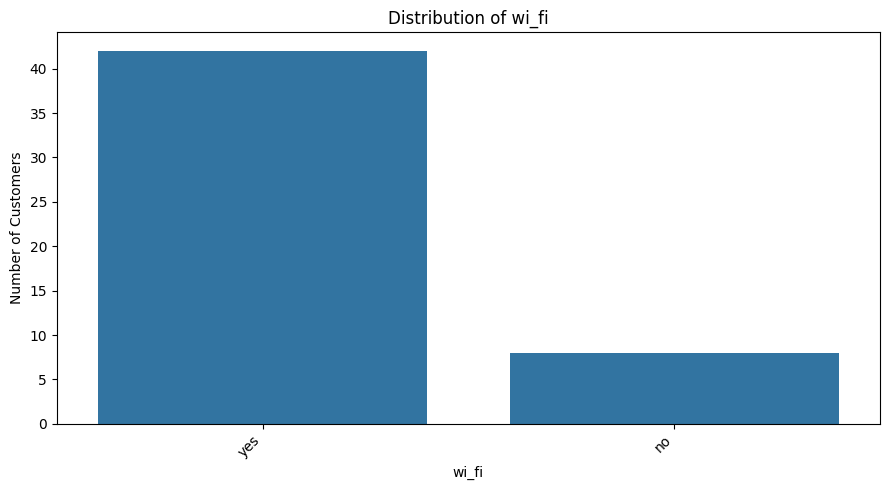

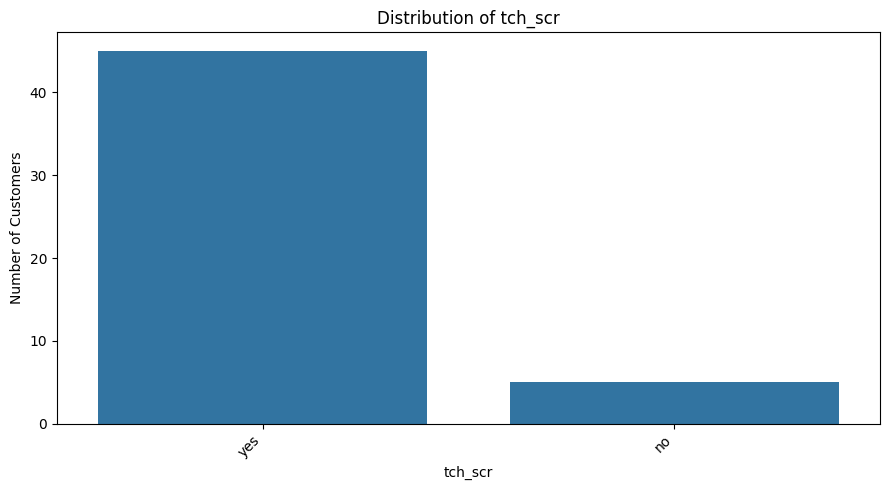

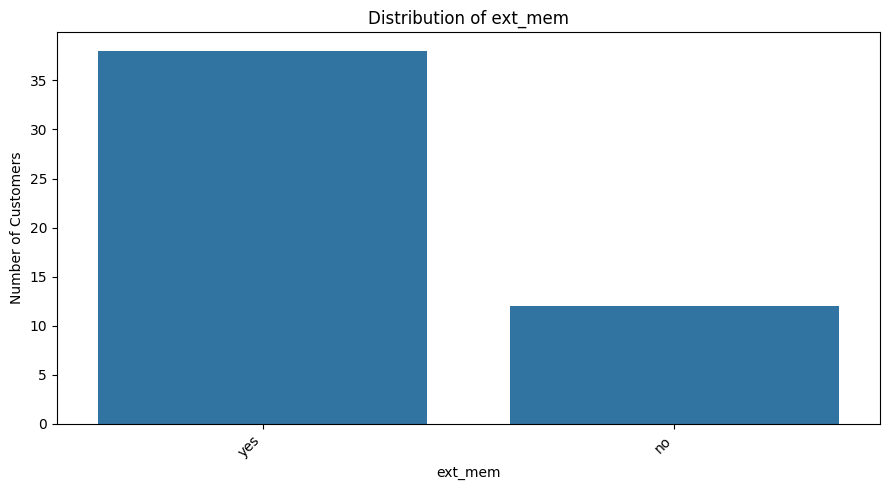

In [7]:
categorical_cols = df.select_dtypes(exclude=np.number).columns.tolist()
print("Categorical columns:", categorical_cols)

for col in categorical_cols:
    counts = df[col].value_counts(dropna=False).head(15)
    plt.figure(figsize=(9, 5))
    sns.barplot(x=counts.index.astype(str), y=counts.values)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Number of Customers")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


# 8. Correlation Analysis

,px_h,px_w,scr_h,scr_w,pc,fc,int_mem,bty_pwr,ram,depth,weight,price
px_h,1.000000,0.962988,0.619936,0.582562,0.634229,0.619173,0.328951,0.391626,0.495757,-0.555409,-0.394854,0.546202
px_w,0.962988,1.000000,0.651433,0.629169,0.697908,0.680534,0.416436,0.445295,0.591360,-0.632620,-0.430937,0.635222
scr_h,0.619936,0.651433,1.000000,0.962787,0.420454,0.395268,0.400244,0.421755,0.448901,-0.531327,-0.292726,0.376118
scr_w,0.582562,0.629169,0.962787,1.000000,0.392552,0.368270,0.393009,0.390155,0.414077,-0.510919,-0.227604,0.345074
pc,0.634229,0.697908,0.420454,0.392552,1.000000,0.966222,0.575898,0.599042,0.612231,-0.395388,-0.257475,0.775305
fc,0.619173,0.680534,0.395268,0.368270,0.966222,1.000000,0.586221,0.573891,0.588815,-0.368024,-0.295842,0.773323
int_mem,0.328951,0.416436,0.400244,0.393009,0.575898,0.586221,1.000000,0.641622,0.579205,-0.357693,-0.273785,0.631335
bty_pwr,0.391626,0.445295,0.421755,0.390155,0.599042,0.573891,0.641622,1.000000,0.667049,-0.309703,-0.105692,0.549662
ram,0.495757,0.591360,0.448901,0.414077,0.612231,0.588815,0.579205,0.667049,1.000000,-0.454605,-0.308239,0.715880
depth,-0.555409,-0.632620,-0.531327,-0.510919,-0.395388,-0.368024,-0.357693,-0.309703,-0.454605,1.000000,0.515679,-0.425357


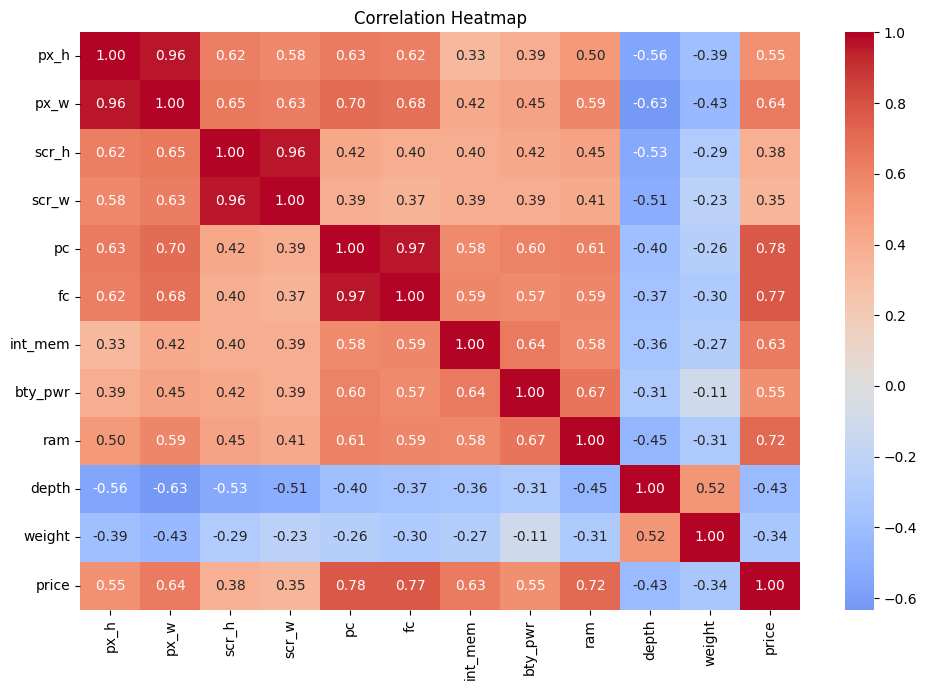

In [8]:
if len(numeric_cols) >= 2:
    correlation = df[numeric_cols].corr()
    display(correlation)

    plt.figure(figsize=(10, 7))
    sns.heatmap(correlation, annot=True, fmt=".2f", cmap="coolwarm", center=0)
    plt.title("Correlation Heatmap")
    plt.tight_layout()
    plt.show()
else:
    print("At least two numerical variables are required for correlation analysis.")


# 10. Key Findings

In [9]:
print("KEY PROJECT FINDINGS")
print("=" * 55)
print("Total customers:", len(df))
print("Total variables:", len(df.columns))
print("Missing cells:", int(df.isnull().sum().sum()))
print("Duplicate rows remaining:", int(df.duplicated().sum()))

print("\nNumerical variable summary:")
for col in numeric_cols:
    print(f"- {col}: minimum = {df[col].min()}, maximum = {df[col].max()}, average = {df[col].mean():.2f}")

print("\nCategorical variable summary:")
for col in categorical_cols:
    print(f"- {col}: {df[col].nunique(dropna=True)} unique categories")


KEY PROJECT FINDINGS
Total customers: 50
Total variables: 17
Missing cells: 0
Duplicate rows remaining: 0

Numerical variable summary:
- px_h: minimum = 780, maximum = 2880, average = 2319.40
- px_w: minimum = 460, maximum = 2520, average = 1833.20
- scr_h: minimum = 2, maximum = 10, average = 6.50
- scr_w: minimum = 1, maximum = 8, average = 4.62
- pc: minimum = 2, maximum = 128, average = 42.16
- fc: minimum = 2, maximum = 64, average = 20.76
- int_mem: minimum = 8, maximum = 1024, average = 173.76
- bty_pwr: minimum = 2300, maximum = 5600, average = 3740.00
- ram: minimum = 2, maximum = 12, average = 5.76
- depth: minimum = 2, maximum = 7, average = 3.44
- weight: minimum = 80, maximum = 400, average = 195.20
- price: minimum = 3297, maximum = 149000, average = 33794.86

Categorical variable summary:
- pid: 50 unique categories
- blue: 2 unique categories
- wi_fi: 2 unique categories
- tch_scr: 2 unique categories
- ext_mem: 2 unique categories


# 11. Conclusion

This Telecom Customer Data Science project demonstrates a complete exploratory analysis workflow.

The dataset was loaded and inspected first. Data cleaning was then performed by checking missing values, identifying duplicate records and standardising column names. Descriptive statistics were used to understand numerical and categorical variables.

Visualisations were created to make the patterns in the data easier to understand. Correlation analysis was also performed for numerical variables. Where a churn field was available, customer churn was analysed along with relevant telecom variables.

This project provides a foundation for more advanced work such as feature engineering, statistical testing and machine learning-based churn prediction.

## Final Learning Outcome

Through this project, I learned how to work with a telecom dataset and apply the main steps of an Exploratory Data Analysis workflow using Python.
